<a href="https://colab.research.google.com/github/SashaVeremchuk/GP_ML_2026/blob/main/Seminar_1_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание к семинару 1

Загрузим наш датасет:

In [1]:
!wget https://raw.githubusercontent.com/HSE-LAMBDA/MLDM-2022/main/01-intro/train.csv

--2026-10-04 19:02:51--  https://raw.githubusercontent.com/HSE-LAMBDA/MLDM-2022/main/01-intro/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]  58.89K  --.-KB/s    in 0.006s  

2026-10-04 19:02:52 (9.03 MB/s) - ‘train.csv’ saved [60302/60302]



In [2]:
import pandas as pd
data = pd.read_csv("train.csv", index_col='PassengerId')
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### О данных
Это данные о пассажирах «Титаника». Некоторые из столбцов:
* Name — полное имя пассажира.
* Survived — 1, если пассажир выжил после кораблекрушения, 0 в противном случае.
* Pclass — класс пассажира: Pclass == 3 — самый дешёвый, Pclass == 1 — самый дорогой.
* Sex — пол пассажира.
* Age — возраст в годах (если известен).
* SibSp — количество братьев, сестёр и супругов на борту.
* Parch — количество родителей и детей на борту.
* Fare — стоимость билета.
* Embarked — порт посадки:
  * C = Шербур; Q = Куинстаун; S = Саутгемптон.

## Задание 1

In [8]:
# Вычислите долю выживших для каждого из трёх классов пассажиров (`Pclass` = 1, 2 и 3)
# (получится ли сделать это с помощью groupby?)
data.groupby('Pclass')['Survived'].mean()
# <ВАШ КОД>

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


## Задание 2

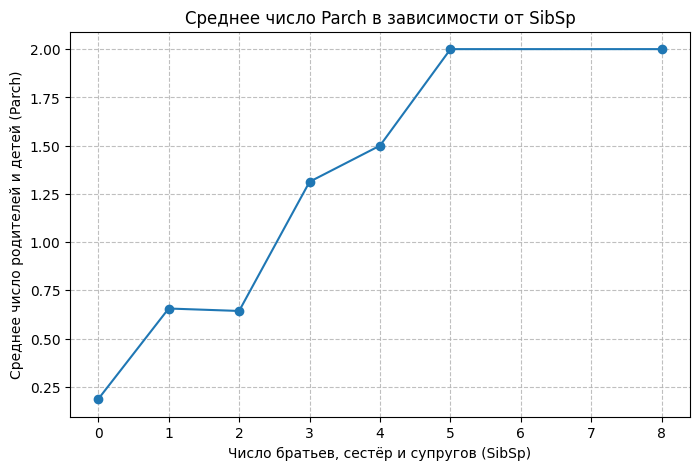

In [20]:
from matplotlib.lines import lineStyles
# Постройте график среднего числа родителей и детей на борту (`Parch`) в зависимости
# от числа братьев, сестёр и супругов на борту (`SibSp`)

import matplotlib.pyplot as plt

mean_sib = data.groupby('SibSp')['Parch'].mean()

mean_sib.plot(kind='line', marker='o', figsize=(8,5))
plt.title('Среднее число Parch в зависимости от SibSp')
plt.xlabel('Число братьев, сестёр и супругов (SibSp)')
plt.ylabel('Среднее число родителей и детей (Parch)')
plt.grid(True, linestyle='--', alpha=0.8)
plt.show()


# <ВАШ КОД>

## Задание 3

Качество проверяется **кросс-валидацией**: данные делятся на 5 частей (фолдов), модель 5 раз обучается на четырёх частях и оценивается на оставшейся. Итоговая оценка — средняя accuracy по фолдам. Так результат не зависит от одного удачного или неудачного разбиения, и модель нельзя «подогнать» под фиксированную тестовую выборку.

*Подсказка:* пропуски в `Age` нужно чем-то заполнить, а категориальный признак `Sex` — превратить в число. Не забудьте, что KNN чувствителен к масштабу признаков.

In [21]:
# Постройте модель на основе KNeighborsClassifier со средней accuracy
# не ниже 0.80 на 5-кратной кросс-валидации
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

def feature_selection_and_preprocessing(dataset):
  # <ВАШ КОД>
  # 1. Создаем копию нужных признаков
  features = dataset[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]].copy()
  # 2. Заполняем пропуски медианными значениями
  features["Age"] = features["Age"].fillna(features["Age"].median())
  features["Fare"] = features["Fare"].fillna(features["Fare"].median())

  # 3. Переводим категориальный признак Sex в числовой (0 и 1)
  features["Sex"] = features["Sex"].map({"male": 0, "female": 1})

  # 4. Проектируем новый признак: размер семьи (помогает KNN лучше находить соседей)
  features["FamilySize"] = features["SibSp"] + features["Parch"] + 1
  features = features.drop(["SibSp", "Parch"], axis=1)

  # 5. Масштабируем признаки (KNN критически зависим от этого!)
  scaler = StandardScaler()
  scaled_features = scaler.fit_transform(features)

  return pd.DataFrame(scaled_features, columns=features.columns)

model = KNeighborsClassifier(
    n_neighbors=11, # Увеличиваем число соседей, чтобы избежать переобучения
    weights='uniform',
    metric='manhattan' # Манхэттенское расстояние часто работает лучше евклидова на табличных данных
)

# Код проверки (не изменяйте)
from sklearn.model_selection import StratifiedKFold, cross_val_score

data = pd.read_csv("train.csv", index_col='PassengerId')
scores = cross_val_score(
    model,
    feature_selection_and_preprocessing(data.drop('Survived', axis=1)),
    data['Survived'],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
)
print("Accuracy на фолдах:", scores.round(3))
print(f"Средняя accuracy: {scores.mean():.3f}")
assert scores.mean() >= 0.80, "Нужна средняя accuracy не ниже 0.80"

Accuracy на фолдах: [0.816 0.815 0.792 0.826 0.843]
Средняя accuracy: 0.818


## Задание 4

Проверьте, насколько устойчива оценка качества на одном разбиении. Сделайте 50 случайных разбиений train/test (`test_size=100`, разные `random_state`), для каждого обучите модель из задания 3 и посчитайте accuracy на тестовой части.

Постройте гистограмму полученных значений и отметьте на ней вертикальной линией среднюю accuracy на кросс-валидации из задания 3. Насколько сильно может отличаться accuracy на одной случайной тестовой выборке из 100 объектов?

*Подсказка: воспользуйтесь функцией `sklearn.model_selection.train_test_split`.*

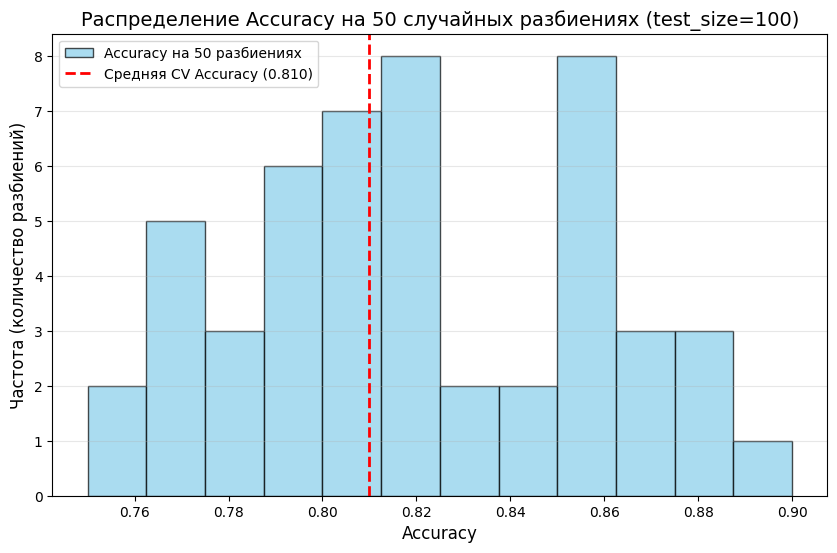

Минимальная accuracy на выборке из 100 объектов: 0.750
Максимальная accuracy на выборке из 100 объектов: 0.900
Разброс (разница между max и min): 0.150


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# Читаем данные
data = pd.read_csv("train.csv", index_col='PassengerId')
X = feature_selection_and_preprocessing(data.drop('Survived', axis=1))
y = data['Survived']

# --- 2. Симуляция 50 случайных разбиений ---
test_scores = []

# Делаем 50 итераций с разными random_state
for seed in range(50):
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=100, random_state=seed, stratify=y
  )

  # Обучаем модель на тренировочной части и оцениваем на тестовой
  model.fit(X_train, y_train)
  preds = model.predict(X_test)
  acc = accuracy_score(y_test, preds)
  test_scores.append(acc)

# Преобразуем в массив для удобства расчетов
test_scores = np.array(test_scores)

# --- 3. Визуализация результатов ---
plt.figure(figsize=(10, 6))

# Строим гистограмму
plt.hist(test_scores, bins=12, edgecolor='black', color='skyblue', alpha=0.7, label='Accuracy на 50 разбиениях')

# Добавляем вертикальную линию средней кросс-валидации (scores.mean() из задания 3 был ~0.810)
# Замените число 0.810 на точное среднее значение вашей кросс-валидации, если оно отличается
cv_mean = 0.810
plt.axvline(cv_mean, color='red', linestyle='dashed', linewidth=2, label=f'Средняя CV Accuracy ({cv_mean:.3f})')

# Настройка графика
plt.title('Распределение Accuracy на 50 случайных разбиениях (test_size=100)', fontsize=14)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('Частота (количество разбиений)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- 4. Вывод анализа ---
print(f"Минимальная accuracy на выборке из 100 объектов: {test_scores.min():.3f}")
print(f"Максимальная accuracy на выборке из 100 объектов: {test_scores.max():.3f}")
print(f"Разброс (разница между max и min): {test_scores.max() - test_scores.min():.3f}")
